# Experiment 12: Answer-Token Probability Trajectory

| | |
|---|---|
| **Author** | Elad Moshe |
| **Supervisors** | Prof. Luciano Dyballa & Prof. Andrea Cremaschi |
| **Institution** | IE Madrid — MSc Computer Science |
| **Date** | June 2026 |
| **Priority** | NICE TO HAVE |
| **Runtime** | Google Colab T4/A100 GPU (~20–25 min total) |


---
**AI Assistance Disclaimer:** Portions of this notebook were generated with the assistance of Claude (Anthropic). All experimental design, interpretation, and conclusions are the author's own.
---


## Overview

**Research question:** At what point in its Chain-of-Thought does the model already "know" the answer it is going to give — and for *incorrect* chains, when does it fixate on the wrong answer while suppressing the correct one?

**Method (Logit-lens trajectory):**
For each generated chain we run a single forward pass and extract, at every token position `t`, the softmax probability assigned to the *answer token*. We track three signals:

| Signal | Correct chains | Incorrect chains |
|---|---|---|
| **P(pred)** | P(correct answer digit) | P(wrong answer digit) |
| **P(gold)** | *(same as P(pred))* | P(gold correct digit) |
| **P(baseline)** | P(' the') — null curve | P(' the') — null curve |

Position is normalised to fraction `[0, 1]` and binned into 20 equal bins (5% each).

**Why single-digit answers only?**  
Gemma-2 tokenises every number digit-by-digit with a separate leading space token:  
`' 132'` → `[SPACE, '1', '3', '2']` — four separate tokens.  
For a multi-digit answer we can only track P(first digit), but '132' and '14' both start with the same digit token '1' — making incorrect vs correct comparisons ambiguous. Single-digit answers (0–9) map to **exactly one token** inside `\boxed{}`, so P(answer token) unambiguously tracks P(this specific answer) throughout the chain.

**Commitment point:** first fraction where P(pred) > 0.01 (1% = 2560× above random chance for Gemma-2's 256K vocabulary).

**Data:** 77 GSM8K problems with single-digit answers filtered from the Exp 11 pool. Exp 12 generates its own chains (Exp 11 captures are not reused). One new forward pass per chain for logit extraction — no re-generation needed.

**Figures produced:**
1. Main probability trajectory (3-panel)
2. Commitment & peak fraction distributions (violin + strip + Mann–Whitney)
3. Per-chain heatmap sorted by commitment point
4. Suppression analysis for incorrect chains only


## 0. Setup


In [ ]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'transformers>=4.40', 'accelerate', 'datasets',
                'sentencepiece', 'protobuf', 'scipy', 'plotly'], check=True)
print('Packages ready.')


In [ ]:
import sys, os, json, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path
from getpass import getpass
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# ── Mount Google Drive ─────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Paths ──────────────────────────────────────────────────────────────────
ROOT         = Path('/content/drive/MyDrive/research capstone/experiments')
NOTEBOOK_DIR = ROOT / 'exp12_answer_probability_trajectory'
EXP7_DIR     = ROOT / 'exp7_gemma3_reference_with_NLA'
EXP7_CACHE   = EXP7_DIR / 'backup' / 'cache'

BACKUP_DIR   = NOTEBOOK_DIR / 'backup'
CACHE_DIR    = BACKUP_DIR   / 'cache'
FIGURES_DIR  = BACKUP_DIR   / 'figures'
CAPTURE_DIR  = CACHE_DIR    / 'e12_captures'   # Exp 12 own chain captures
E12_MANIFEST = CACHE_DIR    / 'e12_manifest.json'

CACHE_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
CAPTURE_DIR.mkdir(parents=True, exist_ok=True)

assert NOTEBOOK_DIR.exists(), f'Exp12 folder not found: {NOTEBOOK_DIR}'
assert EXP7_CACHE.exists(),   f'Exp7 cache not found (need gsm8k parquet): {EXP7_CACHE}'

# ── Constants ──────────────────────────────────────────────────────────────
SEED           = 42
N_PER_CLASS    = 40
N_BINS         = 20      # bins along CoT fraction (5% each)
P_THRESHOLD    = 0.01    # "commitment": first position where P(answer) exceeds 1%
MAX_NEW_TOKENS = 512     # cap on generated tokens per chain
HF_MODEL_ID    = 'google/gemma-2-2b-it'

BIN_CENTERS = np.linspace(2.5, 97.5, N_BINS)
BIN_EDGES   = np.linspace(0, 100, N_BINS + 1)

np.random.seed(SEED)
print(f'NOTEBOOK_DIR : {NOTEBOOK_DIR}')
print(f'CACHE_DIR    : {CACHE_DIR}')
print(f'CAPTURE_DIR  : {CAPTURE_DIR}')
print(f'E12_MANIFEST : {E12_MANIFEST}  (exists={E12_MANIFEST.exists()})')
print(f'N_BINS={N_BINS}  P_THRESHOLD={P_THRESHOLD}  N_PER_CLASS={N_PER_CLASS}')


In [ ]:
import os
from getpass import getpass
os.environ['HF_TOKEN'] = getpass('HuggingFace token (required for Gemma-2): ')
print('HF token ready.')


In [ ]:
import json, numpy as np, pandas as pd

# ── Load full problem set ──────────────────────────────────────────────────
_df_raw = pd.read_parquet(EXP7_CACHE / 'gsm8k_sample_400.parquet')
# Apply same shuffle as Exp 11 for consistent indexing
_df_all  = _df_raw.sample(frac=1, random_state=SEED).reset_index(drop=True)
print(f'Full pool: {len(_df_all)} problems')

# ── Filter to single-digit answers only ───────────────────────────────────
# A single-digit answer (0-9) maps to exactly ONE token after the opening brace,
# making P(answer token) unambiguous — no overlap with multi-digit answers
# that share the same leading digit.
def _is_single_digit(val):
    s = str(val).strip().replace(',','').replace('$','').replace('%','')
    try:    s = str(int(float(s)))
    except: return False
    return len(s) == 1 and s.isdigit()

df_gsm = _df_all[_df_all['gold_answer'].apply(_is_single_digit)].reset_index(drop=True)
print(f'Single-digit answer problems: {len(df_gsm)}'
      f'  (values: {sorted(df_gsm["gold_answer"].astype(str).unique().tolist())})')
print(f'\nExample:')
print(df_gsm[['problem','gold_answer']].head(3).to_string())


### Problem Pool Preview

Re-run the cell below to see a different random 20 from the 77 single-digit problems.


In [ ]:
import random

# Re-run this cell to see a different random 20 from the single-digit pool
_sample = df_gsm.sample(n=min(20, len(df_gsm))).reset_index()

print(f'Single-digit answer pool: {len(df_gsm)} problems  '
      f'(showing 20 random — re-run to reshuffle)\n')
print(f'{"idx":<5} {"Answer":<8} Problem (truncated)')
print('─' * 95)
for _, row in _sample.iterrows():
    prob_short = row['problem'][:115].replace('\n', ' ')
    if len(row['problem']) > 115:
        prob_short += '...'
    print(f'{int(row["index"]):<5} {str(row["gold_answer"]):<8} {prob_short}')

# Save all 77 problems to CSV — open directly in Excel from Drive
df_gsm[['problem', 'gold_answer']].to_csv(NOTEBOOK_DIR / 'e12_single_digit_problems.csv', index_label='idx')
print(f'\nSaved {len(df_gsm)} problems → {NOTEBOOK_DIR / "e12_single_digit_problems.csv"}')


## 1. Generate CoT Chains

Generates and saves CoT chains for the single-digit filtered pool. Resume-safe — skips problems already captured. Targets `N_PER_CLASS` correct + `N_PER_CLASS` incorrect chains.


In [ ]:
import os, torch
from transformers import AutoTokenizer, AutoModelForCausalLM

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

print(f'Loading tokenizer for {HF_MODEL_ID}...')
tokenizer = AutoTokenizer.from_pretrained(HF_MODEL_ID, token=os.environ['HF_TOKEN'])

print(f'Loading {HF_MODEL_ID} in bfloat16...')
model = AutoModelForCausalLM.from_pretrained(
    HF_MODEL_ID,
    token=os.environ['HF_TOKEN'],
    dtype=torch.bfloat16,
    device_map='auto',
)
model.eval()

_dev       = next(model.parameters()).device
VOCAB_SIZE = model.config.vocab_size
print(f'Loaded.  Vocab={VOCAB_SIZE:,}  |  Random-chance P ≈ {1/VOCAB_SIZE:.2e}')
if DEVICE == 'cuda':
    print(f'VRAM used: {torch.cuda.memory_allocated()/1e9:.2f} GB')


### Token ID Verification

Confirms that the digit token returned by `_ans_tok_id` (from `' 7'` encoding) matches the actual token Gemma-2 uses inside `\boxed{7}`. Must print **OK** for all digits before proceeding.


In [ ]:
"""
Verify that the digit token returned by _ans_tok_id (toks[1] from ' 7' encoding)
matches the actual token used for that digit inside \\boxed{7} in generated text.
If these don't match, we'd be tracking the wrong token.
"""
_BOX = chr(92) + 'boxed'

print(f'{"Digit":<6} {"From space-enc toks[1]":<28} {"Inside \\\\boxed{}":<28} {"Match?"}')
print('─' * 80)

all_ok = True
for digit in '0123456789':
    # Token as returned by _ans_tok_id
    space_toks = tokenizer.encode(' ' + digit, add_special_tokens=False)
    tok_from_space = space_toks[1] if len(space_toks) > 1 else space_toks[0]

    # Token as it actually appears inside \boxed{digit}
    boxed_str  = f'{_BOX}{{{digit}}}'
    boxed_toks = tokenizer.encode(boxed_str, add_special_tokens=False)
    boxed_dec  = [tokenizer.decode([t]) for t in boxed_toks]

    tok_in_boxed = None
    for t, dec in zip(boxed_toks, boxed_dec):
        if dec.strip() == digit:
            tok_in_boxed = int(t)
            break

    match = tok_from_space == tok_in_boxed
    if not match:
        all_ok = False
    status = 'OK' if match else 'MISMATCH !!!'
    print(f'  {digit}    toks[1]={tok_from_space:<8} {tokenizer.decode([tok_from_space])!r:<12}'
          f'   \\boxed tok={tok_in_boxed!s:<8} {tokenizer.decode([tok_in_boxed]) if tok_in_boxed else "None"!r:<12}'
          f'   {status}')

print()
if all_ok:
    print('All digits match — _ans_tok_id is tracking the correct token inside \\boxed{}.')
else:
    print('MISMATCH DETECTED — need to find the token by searching gen_ids directly.')


In [ ]:
import re, torch, json, time
import numpy as np

# CAPTURE_DIR and E12_MANIFEST are defined in the setup cell (e12_c00)

_BOX         = chr(92) + 'boxed'
_BOXED_RE    = re.compile(r'\\boxed\{([^}]*)\}')
_NUM_RE      = re.compile(r'-?\d+(?:,\d{3})*(?:\.\d+)?')
_dev         = next(model.parameters()).device

def _clean(s):
    return str(s).strip().replace(',','').replace('$','').replace('%','').strip()

def _extract(text):
    m = _BOXED_RE.findall(text)
    if m:
        try:    return float(_clean(m[-1]))
        except: return _clean(m[-1])
    nums = _NUM_RE.findall(_clean(text))
    return float(nums[-1]) if nums else None

def _correct(pred, gold):
    if pred is None: return False
    try:    return abs(float(_clean(str(pred))) - float(_clean(str(gold)))) < 1e-3
    except: return _clean(str(pred)) == _clean(str(gold))

def _generate(problem):
    prompt_text = tokenizer.apply_chat_template(
        [{'role': 'user', 'content':
          f'Solve this math problem step by step. '
          f'Show your full working, then write your final answer inside {_BOX}{{}}.'
          f'\n\nProblem: {problem}'}],
        tokenize=False, add_generation_prompt=True,
    )
    enc = tokenizer(prompt_text, return_tensors='pt').to(_dev)
    with torch.no_grad():
        out = model.generate(
            enc['input_ids'], attention_mask=enc['attention_mask'],
            max_new_tokens=MAX_NEW_TOKENS, do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    gen_ids  = out[0, enc['input_ids'].shape[1]:].cpu().numpy().astype(np.int32)
    gen_text = tokenizer.decode(gen_ids, skip_special_tokens=True)
    return gen_ids, gen_text, _extract(gen_text)

# ── Resume-aware capture loop ──────────────────────────────────────────────
manifest   = json.loads(E12_MANIFEST.read_text()) if E12_MANIFEST.exists() else []
done_ids   = {m['idx'] for m in manifest}
n_correct  = sum(1 for m in manifest if     m['correct'])
n_incorrect= sum(1 for m in manifest if not m['correct'])
print(f'Resuming: {len(manifest)} done  ({n_correct} correct, {n_incorrect} incorrect)')
print(f'Pool: {len(df_gsm)} single-digit problems  |  Target: {N_PER_CLASS}+{N_PER_CLASS}')

_t0 = time.time()
for _idx, _row in df_gsm.iterrows():
    if n_correct >= N_PER_CLASS and n_incorrect >= N_PER_CLASS:
        break
    if _idx in done_ids:
        continue
    _gold = str(_row['gold_answer']).strip()
    print(f'[{_idx:3d}] c={n_correct}/{N_PER_CLASS} i={n_incorrect}/{N_PER_CLASS} ... ',
          end='', flush=True)
    _t1 = time.time()
    try:
        gen_ids, gen_text, pred = _generate(_row['problem'])
    except Exception as e:
        print(f'ERROR: {e}')
        continue
    ok = _correct(pred, _gold)
    np.savez_compressed(CAPTURE_DIR / f'e12_problem_{_idx:04d}.npz', gen_ids=gen_ids)
    manifest.append({
        'idx': int(_idx), 'problem': _row['problem'][:200],
        'gold': _gold, 'pred': str(pred), 'correct': bool(ok),
        'gen_text': gen_text[:300], 'file': f'e12_problem_{_idx:04d}.npz',
        'n_tokens': int(len(gen_ids)),
    })
    E12_MANIFEST.write_text(json.dumps(manifest, indent=2))
    if ok: n_correct   += 1
    else:  n_incorrect += 1
    done_ids.add(_idx)
    print(f'correct={ok}  n_tok={len(gen_ids)}  {time.time()-_t1:.0f}s')

print(f'\nCapture complete in {(time.time()-_t0)/60:.1f} min')
print(f'correct={n_correct}  incorrect={n_incorrect}  total={len(manifest)}')
if n_correct < N_PER_CLASS or n_incorrect < N_PER_CLASS:
    print(f'WARNING: pool exhausted before reaching N_PER_CLASS={N_PER_CLASS}')
    print(f'Will use {min(n_correct,n_incorrect)} per class (balanced)')


## 2. Logit Trajectory Extraction

For each captured chain: reconstruct the exact prompt, concatenate with saved `gen_ids`, run one forward pass, extract P(pred), P(gold), P(baseline) at every generated position via numerically-stable log-sum-exp. Bin into 20 CoT-fraction buckets and cache to Drive.

**Memory note:** Only 3 probabilities per position are materialised; full (n_gen × 256K) softmax is avoided using the log-sum-exp trick.


In [ ]:
import json, torch, time
import numpy as np

TRAJ_CACHE = CACHE_DIR / 'e12_trajectories.json'
_BOX       = chr(92) + 'boxed'

# Baseline token: ' the' — a common function word, never a numeric answer
BASELINE_TOK = tokenizer.encode(' the', add_special_tokens=False)[0]
print(f'Baseline token: id={BASELINE_TOK}  repr={tokenizer.decode([BASELINE_TOK])!r}')
print(f'Random-chance P ≈ {1/VOCAB_SIZE:.2e}  |  Threshold={P_THRESHOLD} '
      f'({P_THRESHOLD*VOCAB_SIZE:.0f}× above chance)')

def _ans_tok_id(ans_str: str) -> int:
    """Return the digit token ID for a single-digit answer.

    Gemma-2 tokenises ' 7' as [SPACE_TOKEN, '7_TOKEN'] — two tokens.
    For single-digit answers the digit token (toks[1]) is unambiguous:
    it uniquely identifies the answer and is the same token that appears
    inside \\boxed{7} in the generated sequence.
    """
    s = str(ans_str).strip()
    try:
        s = str(int(float(s.replace(',', '').replace('$', '').replace('%', ''))))
    except Exception:
        pass
    if s in ('None', '', 'nan') or not s.isdigit() or len(s) != 1:
        return BASELINE_TOK
    toks = tokenizer.encode(' ' + s, add_special_tokens=False)
    # toks[0] = leading space (id 235248, same for every number) — skip
    # toks[1] = digit token — uniquely identifies a single-digit answer
    if len(toks) > 1:
        return int(toks[1])
    return int(toks[0]) if toks else BASELINE_TOK

def _bin_vec(vec: np.ndarray, n_gen: int) -> list:
    """Bin vec (len=n_gen) into N_BINS equal-fraction buckets, return mean per bin."""
    fracs = np.arange(n_gen) / n_gen
    bins  = np.floor(fracs * N_BINS).astype(int).clip(0, N_BINS - 1)
    return [
        float(vec[bins == b].mean()) if (bins == b).any() else float('nan')
        for b in range(N_BINS)
    ]

# ── Load Exp 12 manifest and balance classes ───────────────────────────────
if not E12_MANIFEST.exists():
    raise RuntimeError(
        f'Manifest not found: {E12_MANIFEST}\n'
        f'Run the capture cell (e12_c03b) first to generate chains.'
    )
_manifest_all = json.loads(E12_MANIFEST.read_text())
_correct_all   = [m for m in _manifest_all if     m['correct']]
_incorrect_all = [m for m in _manifest_all if not m['correct']]
n_each = min(N_PER_CLASS, len(_correct_all), len(_incorrect_all))
import random; random.seed(SEED)
chains = (random.sample(_correct_all,   n_each) +
          random.sample(_incorrect_all, n_each))
print(f'Manifest: {len(_manifest_all)} total  →  using {n_each}+{n_each}={2*n_each} balanced chains')

# Verify all capture files exist
_missing = [m for m in chains if not (CAPTURE_DIR / m['file']).exists()]
if _missing:
    print(f'ERROR: {len(_missing)} capture files missing — re-run capture cell')
    raise FileNotFoundError(f'Missing: {_missing[0]["file"]}')

trajectories = None
_SPACE_TOK   = 235248  # leading space token — if used as answer tok, cache is stale

if TRAJ_CACHE.exists():
    _cached = json.loads(TRAJ_CACHE.read_text())
    _n_bad  = sum(1 for t in _cached if t['gold_tok_id'] == _SPACE_TOK)
    if _n_bad > 0:
        print(f'[CACHE] STALE — {_n_bad}/{len(_cached)} entries use space token as answer. Recomputing.')
        TRAJ_CACHE.unlink()
    else:
        trajectories = _cached
        print(f'[CACHE] Loaded {len(trajectories)} valid trajectories')

if trajectories is None:
    _dev         = next(model.parameters()).device
    trajectories = []
    _t0          = time.time()

    for m in tqdm(chains, desc='Logit trajectory extraction'):
        pred_tok = _ans_tok_id(m['pred'])
        gold_tok = _ans_tok_id(m['gold'])

        problem = df_gsm.loc[m['idx'], 'problem']
        prompt_text = tokenizer.apply_chat_template(
            [{'role': 'user', 'content':
              f'Solve this math problem step by step. '
              f'Show your full working, then write your final answer inside {_BOX}{{}}.'
              f'\n\nProblem: {problem}'}],
            tokenize=False, add_generation_prompt=True,
        )
        prompt_enc = tokenizer(prompt_text, return_tensors='pt')
        prompt_len = prompt_enc['input_ids'].shape[1]

        # Load gen_ids from Exp 12's own captures
        gen_ids = np.load(CAPTURE_DIR / m['file'])['gen_ids'].astype(np.int64)
        n_gen   = len(gen_ids)

        gen_tensor = torch.tensor(gen_ids, dtype=torch.long).unsqueeze(0)
        full_ids   = torch.cat([prompt_enc['input_ids'], gen_tensor], dim=1).to(_dev)

        with torch.no_grad():
            logits = model(full_ids).logits  # (1, full_len, vocab)

        # logits[0, prompt_len-1+i, :] predicts generated token i
        gen_logits = logits[0, prompt_len - 1 : prompt_len - 1 + n_gen, :]

        # Numerically stable: extract P for 3 tokens without full softmax
        tok_ids = torch.tensor([pred_tok, gold_tok, BASELINE_TOK], device=_dev)
        log_Z   = torch.logsumexp(gen_logits, dim=-1, keepdim=True)
        probs3  = (gen_logits[:, tok_ids] - log_Z).exp().float().cpu().numpy()

        del logits, gen_logits, log_Z, full_ids
        torch.cuda.empty_cache()

        p_pred = probs3[:, 0]
        p_gold = probs3[:, 1]
        p_base = probs3[:, 2]

        above       = np.where(p_pred > P_THRESHOLD)[0]
        commit_frac = float(above[0] / n_gen) if len(above) > 0 else 1.0

        trajectories.append({
            'idx':            int(m['idx']),
            'correct':        bool(m['correct']),
            'pred_answer':    str(m['pred']),
            'gold_answer':    str(m['gold']),
            'pred_tok_id':    pred_tok,
            'gold_tok_id':    gold_tok,
            'same_first_tok': (pred_tok == gold_tok and not m['correct']),
            'n_gen':          int(n_gen),
            'p_pred_binned':  _bin_vec(p_pred, n_gen),
            'p_gold_binned':  _bin_vec(p_gold, n_gen),
            'p_base_binned':  _bin_vec(p_base, n_gen),
            'commit_frac':    commit_frac,
            'peak_frac':      float(np.argmax(p_pred) / n_gen),
            'p_pred_first':   float(p_pred[0]),
            'p_pred_last':    float(p_pred[-1]),
            'p_pred_max':     float(p_pred.max()),
            'p_gold_max':     float(p_gold.max()),
        })

    TRAJ_CACHE.write_text(json.dumps(trajectories, indent=2))
    print(f'\nDone in {(time.time()-_t0)/60:.1f} min  |  {len(trajectories)} trajectories saved')

# ── Summary ────────────────────────────────────────────────────────────────
_c     = [t for t in trajectories if     t['correct']]
_i     = [t for t in trajectories if not t['correct']]
_ambig = [t for t in _i if t['same_first_tok']]
print(f'\nCorrect   (n={len(_c)}):  '
      f'mean commit={np.mean([t["commit_frac"] for t in _c]):.3f}  '
      f'mean peak={np.mean([t["peak_frac"] for t in _c]):.3f}')
print(f'Incorrect (n={len(_i)}):  '
      f'mean commit={np.mean([t["commit_frac"] for t in _i]):.3f}  '
      f'mean peak={np.mean([t["peak_frac"] for t in _i]):.3f}')
print(f'Ambiguous pred/gold tok pairs: {len(_ambig)}/{len(_i)}'
      f'  (should be near 0 for single-digit filtered data)')

# Sanity check — print digit token IDs used
_pred_toks = set(t['pred_tok_id'] for t in _i)
_gold_toks = set(t['gold_tok_id'] for t in _i)
print(f'\nDistinct pred tok IDs in incorrect chains: {sorted(_pred_toks)}')
print(f'Distinct gold tok IDs in incorrect chains: {sorted(_gold_toks)}')


## 3. Figures


### Figure 1 — Main Probability Trajectory


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

_c = [t for t in trajectories if     t['correct']]
_i = [t for t in trajectories if not t['correct']]

def _stack(trajs, key):
    return np.array([t[key] for t in trajs], dtype=float)

c_pred = _stack(_c, 'p_pred_binned')   # (40, 20) — P(correct answer) for correct chains
i_pred = _stack(_i, 'p_pred_binned')   # (40, 20) — P(wrong answer) for incorrect chains
i_gold = _stack(_i, 'p_gold_binned')   # (40, 20) — P(gold answer)  for incorrect chains
c_base = _stack(_c, 'p_base_binned')
i_base = _stack(_i, 'p_base_binned')

C_CORR  = '#1565C0'   # blue   — correct chains
C_WRONG = '#C62828'   # red    — wrong answer in incorrect chains
C_GOLD  = '#E65100'   # amber  — gold correct answer (in incorrect chains)
C_BASE  = '#757575'   # grey   — baseline

def _band(ax, x, mat, color, label, ls='-', alpha_line=1.0, alpha_band=0.15):
    m, s = np.nanmean(mat, 0), np.nanstd(mat, 0)
    ax.plot(x, m, color=color, lw=2, ls=ls, label=label, alpha=alpha_line)
    ax.fill_between(x, m - s, m + s, color=color, alpha=alpha_band)
    return m

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(
    'Exp 12 — Answer-Token Probability Trajectory  (Gemma-2-2B-IT, GSM8K)\n'
    f'n={len(_c)} correct + {len(_i)} incorrect  ·  {N_BINS} bins (5% each)  ·  '
    f'commitment threshold = {P_THRESHOLD}',
    fontsize=11, fontweight='bold', y=1.01,
)

# ── Panel A: Correct chains ────────────────────────────────────────────────
ax = axes[0]
_band(ax, BIN_CENTERS, c_pred, C_CORR, 'P(correct answer)  ±1 std')
ax.plot(BIN_CENTERS, np.nanmean(c_base, 0), color=C_BASE, lw=1.2, ls=':',
        label='Baseline  P(" the")')
ax.axhline(P_THRESHOLD, color='black', lw=0.8, ls='--', alpha=0.45,
           label=f'Commitment threshold ({P_THRESHOLD})')
ax.set_title('A — Correct Chains', fontweight='bold', pad=6)
ax.set_xlabel('CoT Position (%)')
ax.set_ylabel('Mean Probability of Answer Token')
ax.set_xlim(0, 100)
ax.set_ylim(bottom=0)
ax.legend(fontsize=8, loc='upper left')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.3f}'))

# ── Panel B: Incorrect chains — fixation vs suppression ───────────────────
ax = axes[1]
m_wrong = _band(ax, BIN_CENTERS, i_pred, C_WRONG, 'P(wrong answer given)  ±1 std')
m_gold  = _band(ax, BIN_CENTERS, i_gold, C_GOLD,  'P(gold correct answer)  ±1 std',
                ls='--')
ax.fill_between(BIN_CENTERS, m_gold, m_wrong,
                where=(m_wrong >= m_gold), color=C_WRONG, alpha=0.10,
                label='Suppression gap  (wrong > gold)')
ax.plot(BIN_CENTERS, np.nanmean(i_base, 0), color=C_BASE, lw=1.2, ls=':',
        label='Baseline  P(" the")')
ax.axhline(P_THRESHOLD, color='black', lw=0.8, ls='--', alpha=0.45)
ax.set_title('B — Incorrect Chains: Fixation vs Suppression', fontweight='bold', pad=6)
ax.set_xlabel('CoT Position (%)')
ax.set_ylabel('Mean Probability')
ax.set_xlim(0, 100)
ax.set_ylim(bottom=0)
ax.legend(fontsize=8, loc='upper left')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.3f}'))

# ── Panel C: Direct comparison — P(their answer): correct vs incorrect ─────
ax = axes[2]
_band(ax, BIN_CENTERS, c_pred, C_CORR,  f'Correct (n={len(_c)})')
_band(ax, BIN_CENTERS, i_pred, C_WRONG, f'Incorrect (n={len(_i)})')
ax.axhline(P_THRESHOLD, color='black', lw=0.8, ls='--', alpha=0.45,
           label=f'Commitment threshold')
ax.set_title('C — P(Their Answer): Correct vs Incorrect', fontweight='bold', pad=6)
ax.set_xlabel('CoT Position (%)')
ax.set_ylabel('Mean Probability of Answer Token')
ax.set_xlim(0, 100)
ax.set_ylim(bottom=0)
ax.legend(fontsize=9, loc='upper left')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.3f}'))

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'exp12_fig1_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: exp12_fig1_trajectories.png')


### Figure 2 — Commitment & Peak Distributions


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

_c = [t for t in trajectories if     t['correct']]
_i = [t for t in trajectories if not t['correct']]

cc = [t['commit_frac'] for t in _c]
ic = [t['commit_frac'] for t in _i]
cp = [t['peak_frac']   for t in _c]
ip = [t['peak_frac']   for t in _i]

# Stats
u_commit, p_commit = stats.mannwhitneyu(cc, ic, alternative='two-sided')
u_peak,   p_peak   = stats.mannwhitneyu(cp, ip, alternative='two-sided')

df_commit = pd.DataFrame({
    'Group':    ['Correct'] * len(cc) + ['Incorrect'] * len(ic),
    'Fraction': cc + ic,
    'Type':     'Commitment',
})
df_peak = pd.DataFrame({
    'Group':    ['Correct'] * len(cp) + ['Incorrect'] * len(ip),
    'Fraction': cp + ip,
    'Type':     'Peak',
})

PAL = {'Correct': '#1565C0', 'Incorrect': '#C62828'}
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
fig.suptitle(
    f'Exp 12 — Commitment & Peak Fraction Distributions  (n={len(_c)}+{len(_i)})',
    fontweight='bold',
)

for ax, df, title, u, p in [
    (axes[0], df_commit, f'Commitment Point\n(first position where P > {P_THRESHOLD})', u_commit, p_commit),
    (axes[1], df_peak,   'Peak Probability Position\n(argmax of P trajectory)',          u_peak,   p_peak),
]:
    sns.violinplot(data=df, x='Group', y='Fraction', palette=PAL,
                   inner=None, alpha=0.55, ax=ax, order=['Correct','Incorrect'])
    sns.stripplot(data=df,  x='Group', y='Fraction', palette=PAL,
                  jitter=True, size=5, alpha=0.7, ax=ax, order=['Correct','Incorrect'])
    ax.axhline(0.5, color='black', lw=1, ls='--', alpha=0.35, label='50% mark')

    # Annotate means
    for xi, (grp, vals) in enumerate([('Correct', cc if 'Commit' in title else cp),
                                       ('Incorrect', ic if 'Commit' in title else ip)]):
        mu = np.mean(vals)
        ax.plot([xi - 0.15, xi + 0.15], [mu, mu], color='black', lw=2.5, zorder=10)
        ax.text(xi, mu + 0.06, f'μ = {mu:.2f}', ha='center', fontsize=9, fontweight='bold')

    ax.set_title(title, fontweight='bold', pad=8)
    ax.set_ylabel('CoT Fraction  (0 = start · 1 = end)')
    ax.set_ylim(-0.05, 1.12)
    ax.set_xlabel('')
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
    ax.text(0.5, -0.13, f'Mann–Whitney  U={u:.0f}  p={p:.4f}  {sig}',
            transform=ax.transAxes, ha='center', fontsize=8.5, color='#333333')
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'exp12_fig2_commitment.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: exp12_fig2_commitment.png')
print(f'\nCommitment:  correct μ={np.mean(cc):.3f}  incorrect μ={np.mean(ic):.3f}  '
      f'p={p_commit:.4f}')
print(f'Peak:        correct μ={np.mean(cp):.3f}  incorrect μ={np.mean(ip):.3f}  '
      f'p={p_peak:.4f}')


### Figure 3 — Per-Chain Heatmap


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Sort chains by commitment fraction (earliest committers at top)
_c = sorted([t for t in trajectories if     t['correct']], key=lambda t: t['commit_frac'])
_i = sorted([t for t in trajectories if not t['correct']], key=lambda t: t['commit_frac'])

c_mat = np.array([t['p_pred_binned'] for t in _c])  # (n, N_BINS)
i_mat = np.array([t['p_pred_binned'] for t in _i])  # (n, N_BINS)
c_commit = [t['commit_frac'] for t in _c]
i_commit = [t['commit_frac'] for t in _i]

# Colour scale: 95th-percentile cap so sparse early signal is visible
vmax = np.nanpercentile(np.concatenate([c_mat, i_mat]), 95)

BIN_LABELS = [f'{int(v)}%' if j % 4 == 0 else '' for j, v in enumerate(BIN_CENTERS)]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle(
    'Exp 12 — Heatmap: P(Answer Token) Across CoT\n'
    'Rows = individual chains sorted by commitment point (earliest at top)\n'
    '▶ marker = commitment fraction per chain',
    fontweight='bold', y=1.02,
)

def _draw_heatmap(ax, mat, commit_list, title, cmap):
    im = ax.imshow(mat, aspect='auto', cmap=cmap,
                   vmin=0, vmax=vmax, interpolation='nearest',
                   extent=[0, N_BINS, len(mat), 0])

    # X-axis: bin labels
    ax.set_xticks(np.arange(N_BINS) + 0.5)
    ax.set_xticklabels(BIN_LABELS, fontsize=7)
    ax.set_xlabel('CoT Position (%)')

    # Y-axis: commitment fraction labels
    ax.set_yticks(np.arange(len(mat)) + 0.5)
    ax.set_yticklabels([f'{f:.0%}' for f in commit_list], fontsize=5.5)
    ax.set_ylabel('Chain  (label = commitment fraction)')

    # Mark commitment point per chain with a white triangle
    for row_i, cf in enumerate(commit_list):
        col_i = min(cf * N_BINS, N_BINS - 0.6)
        ax.scatter(col_i, row_i + 0.5, marker='>', color='white',
                   s=28, zorder=6, linewidths=0.5, edgecolors='grey')

    ax.set_title(title, fontweight='bold', pad=6)
    cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.03)
    cbar.set_label('P(answer token)', fontsize=8)
    return im

_draw_heatmap(axes[0], c_mat, c_commit,
              f'Correct Chains (n={len(_c)})  —  P(correct answer)', 'Blues')
_draw_heatmap(axes[1], i_mat, i_commit,
              f'Incorrect Chains (n={len(_i)})  —  P(wrong answer given)', 'Reds')

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'exp12_fig3_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: exp12_fig3_heatmap.png')


### Figure 4 — Suppression Analysis (Incorrect Chains)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

_i = [t for t in trajectories if not t['correct']]

i_pred = np.array([t['p_pred_binned'] for t in _i])   # P(wrong answer)
i_gold = np.array([t['p_gold_binned'] for t in _i])   # P(gold correct answer)

m_wrong = np.nanmean(i_pred, 0)
s_wrong = np.nanstd(i_pred,  0)
m_gold  = np.nanmean(i_gold, 0)
s_gold  = np.nanstd(i_gold,  0)
delta   = m_wrong - m_gold   # positive → wrong answer dominates

max_wrong  = np.array([t['p_pred_max'] for t in _i])
max_gold   = np.array([t['p_gold_max'] for t in _i])
commits    = np.array([t['commit_frac'] for t in _i])

C_WRONG = '#C62828'
C_GOLD  = '#E65100'

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(
    f'Exp 12 — Suppression Analysis: Incorrect Chains Only (n={len(_i)})\n'
    'How the wrong answer dominates over the gold correct answer through the CoT',
    fontweight='bold', y=1.01,
)

# ── Panel A: Trajectories with filled suppression gap ─────────────────────
ax = axes[0]
ax.plot(BIN_CENTERS, m_wrong, color=C_WRONG, lw=2,    label='P(wrong answer given)')
ax.fill_between(BIN_CENTERS, m_wrong - s_wrong, m_wrong + s_wrong,
                color=C_WRONG, alpha=0.12)
ax.plot(BIN_CENTERS, m_gold, color=C_GOLD, lw=2, ls='--',
        label='P(gold correct answer)')
ax.fill_between(BIN_CENTERS, m_gold - s_gold, m_gold + s_gold,
                color=C_GOLD, alpha=0.12)

# Fill the gap between curves
ax.fill_between(BIN_CENTERS, m_gold, m_wrong,
                where=(m_wrong >= m_gold), color=C_WRONG, alpha=0.18,
                label='Suppression gap  (wrong > gold)')
ax.fill_between(BIN_CENTERS, m_wrong, m_gold,
                where=(m_gold > m_wrong), color=C_GOLD, alpha=0.18,
                label='Reversal  (gold > wrong)')

ax.axhline(P_THRESHOLD, color='black', lw=0.8, ls=':', alpha=0.5,
           label=f'Commitment threshold ({P_THRESHOLD})')
ax.set_title('A — Trajectories + Suppression Gap', fontweight='bold', pad=6)
ax.set_xlabel('CoT Position (%)')
ax.set_ylabel('Mean Probability')
ax.set_xlim(0, 100)
ax.set_ylim(bottom=0)
ax.legend(fontsize=7.5, loc='upper left')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.3f}'))

# ── Panel B: Δ = P(wrong) − P(gold) per bin ────────────────────────────
ax = axes[1]
colors_b = [C_WRONG if d > 0 else C_GOLD for d in delta]
ax.bar(BIN_CENTERS, delta, width=100/N_BINS * 0.85,
       color=colors_b, alpha=0.85, edgecolor='white', linewidth=0.5)
ax.axhline(0, color='black', lw=1)
ax.set_title('B — P(wrong) − P(gold correct)  per bin', fontweight='bold', pad=6)
ax.set_xlabel('CoT Position (%)')
ax.set_ylabel('Probability Difference')
ax.set_xlim(0, 100)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:+.3f}'))

# Annotate first bin where wrong clearly dominates
_dom_bins = np.where(delta > P_THRESHOLD / 2)[0]
if len(_dom_bins):
    first_dom_pct = BIN_CENTERS[_dom_bins[0]]
    ax.axvline(first_dom_pct, color=C_WRONG, lw=1.5, ls='--', alpha=0.7)
    ax.text(first_dom_pct + 1, ax.get_ylim()[1] * 0.9,
            f'First dom.\n@ {first_dom_pct:.0f}%', color=C_WRONG, fontsize=8)

# ── Panel C: Per-chain scatter — max P(wrong) vs max P(gold) ─────────────
ax = axes[2]
sc = ax.scatter(max_gold, max_wrong,
                c=commits, cmap='RdYlGn_r',
                s=65, alpha=0.85, edgecolors='k', linewidths=0.5,
                vmin=0, vmax=1)
_lim = max(max_wrong.max(), max_gold.max()) * 1.08
ax.plot([0, _lim], [0, _lim], 'k--', lw=1, alpha=0.4, label='y = x  (equal)')
ax.set_xlim(0, _lim)
ax.set_ylim(0, _lim)
ax.set_xlabel('Max P(gold correct answer)')
ax.set_ylabel('Max P(wrong answer given)')
ax.set_title('C — Per-Chain Max Probabilities\n(below y=x → wrong dominates)',
             fontweight='bold', pad=6)

cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Commitment fraction\n(red = early · green = late)', fontsize=7.5)
ax.legend(fontsize=8, loc='lower right')

n_dominated = int((max_wrong > max_gold).sum())
ax.text(0.04, 0.96,
        f'{n_dominated}/{len(_i)} chains:\nmax P(wrong) > max P(gold)',
        transform=ax.transAxes, fontsize=9, color=C_WRONG,
        fontweight='bold', va='top')

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'exp12_fig4_suppression.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: exp12_fig4_suppression.png')
print(f'\nChains where max P(wrong) > max P(gold): {n_dominated}/{len(_i)}')
print(f'Mean Δ at peak: {float(np.mean(max_wrong - max_gold)):+.4f}')
print(f'First bin where wrong dominates: {first_dom_pct if len(_dom_bins) else "never"}%')


## 4. Summary Statistics


In [ ]:
import numpy as np
from scipy import stats

_c = [t for t in trajectories if     t['correct']]
_i = [t for t in trajectories if not t['correct']]

cc, ic = [t['commit_frac'] for t in _c], [t['commit_frac'] for t in _i]
cp, ip = [t['peak_frac']   for t in _c], [t['peak_frac']   for t in _i]
cm, im = [t['p_pred_max']  for t in _c], [t['p_pred_max']  for t in _i]
ig     = [t['p_gold_max']  for t in _i]

_, p_c = stats.mannwhitneyu(cc, ic, alternative='two-sided')
_, p_p = stats.mannwhitneyu(cp, ip, alternative='two-sided')
_, p_m = stats.mannwhitneyu(cm, im, alternative='two-sided')

print('=' * 68)
print('  EXP 12 — ANSWER-TOKEN PROBABILITY TRAJECTORY — SUMMARY')
print('=' * 68)
print(f'  Model : Gemma-2-2B-IT  |  GSM8K  |  N_BINS={N_BINS}  |  threshold={P_THRESHOLD}')
print(f'  n     : {len(_c)} correct + {len(_i)} incorrect = {len(trajectories)} chains')
print()
print('  COMMITMENT FRACTION  (first bin where P(answer) > threshold):')
print(f'    Correct    : mean={np.mean(cc):.3f}  median={np.median(cc):.3f}  std={np.std(cc):.3f}')
print(f'    Incorrect  : mean={np.mean(ic):.3f}  median={np.median(ic):.3f}  std={np.std(ic):.3f}')
print(f'    Mann-Whitney p = {p_c:.4f}')
print()
print('  PEAK FRACTION  (where P(answer) is highest):')
print(f'    Correct    : mean={np.mean(cp):.3f}  median={np.median(cp):.3f}')
print(f'    Incorrect  : mean={np.mean(ip):.3f}  median={np.median(ip):.3f}')
print(f'    Mann-Whitney p = {p_p:.4f}')
print()
print('  MAXIMUM P REACHED:')
print(f'    Correct    : mean={np.mean(cm):.4f}  median={np.median(cm):.4f}')
print(f'    Incorrect  : mean={np.mean(im):.4f}  median={np.median(im):.4f}')
print(f'    Mann-Whitney p = {p_m:.4f}')
print()
print('  SUPPRESSION (incorrect chains — wrong vs gold answer):')
n_dom = sum(t['p_pred_max'] > t['p_gold_max'] for t in _i)
print(f'    Chains where max P(wrong) > max P(gold) : {n_dom}/{len(_i)}')
print(f'    Mean max P(wrong)  : {np.mean(im):.4f}')
print(f'    Mean max P(gold)   : {np.mean(ig):.4f}')
print(f'    Mean suppression Δ : {np.mean(np.array(im)-np.array(ig)):+.4f}')
ambig = sum(t['same_first_tok'] for t in _i)
if ambig:
    print(f'    Note: {ambig} chains share pred/gold first token (conservative comparison)')
print('=' * 68)


## 5. Example Chains — All Digit Probabilities

2 correct + 2 incorrect chains selected for maximum signal clarity. Each panel shows P(digit 0–9) across the CoT fraction: **green = gold correct answer**, **red = wrong predicted answer**, grey = all other digits. Vertical dashed line = commitment point.


In [ ]:
import json, torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Digit token IDs for 0-9 ───────────────────────────────────────────────
# Each digit after a space: ' 7' → [SPACE, '7'] → toks[1] is the digit token
DIGIT_TOKS = [
    int(tokenizer.encode(' ' + d, add_special_tokens=False)[1])
    for d in '0123456789'
]
print('Digit token IDs (0-9):', DIGIT_TOKS)

# ── Pick 4 example chains ─────────────────────────────────────────────────
# Correct: 2 with highest max P(pred) — clearest "knew the answer" signal
# Incorrect: 2 with different gold vs pred digit — clean suppression case
_c_sorted = sorted([t for t in trajectories if     t['correct']],
                   key=lambda t: -t['p_pred_max'])
_i_sorted = sorted([t for t in trajectories if not t['correct']
                    and t['pred_tok_id'] != t['gold_tok_id']],
                   key=lambda t: -t['p_pred_max'])

examples = _c_sorted[:2] + _i_sorted[:2]
if len(examples) < 4:
    # Fallback: any incorrect, even with same first digit
    examples = _c_sorted[:2] + [t for t in trajectories if not t['correct']][:2]

print(f'Showing: '
      f'{[(e["gold_answer"], e["pred_answer"], e["correct"]) for e in examples]}')

# ── Forward pass helper — returns P(digit 0-9) at each generated position ─
_dev = next(model.parameters()).device
_BOX = chr(92) + 'boxed'
_all_tok_tensor = torch.tensor(DIGIT_TOKS, device=_dev)

def _get_digit_probs(m):
    problem = df_gsm.loc[m['idx'], 'problem']
    prompt_text = tokenizer.apply_chat_template(
        [{'role': 'user', 'content':
          f'Solve this math problem step by step. '
          f'Show your full working, then write your final answer inside {_BOX}{{}}.'
          f'\n\nProblem: {problem}'}],
        tokenize=False, add_generation_prompt=True,
    )
    prompt_enc = tokenizer(prompt_text, return_tensors='pt')
    prompt_len = prompt_enc['input_ids'].shape[1]

    gen_ids    = np.load(CAPTURE_DIR / f'e12_problem_{m["idx"]:04d}.npz')['gen_ids'].astype(np.int64)
    gen_tensor = torch.tensor(gen_ids, dtype=torch.long).unsqueeze(0)
    full_ids   = torch.cat([prompt_enc['input_ids'], gen_tensor], dim=1).to(_dev)

    with torch.no_grad():
        logits = model(full_ids).logits
    gen_logits = logits[0, prompt_len - 1 : prompt_len - 1 + len(gen_ids), :]

    log_Z      = torch.logsumexp(gen_logits, dim=-1, keepdim=True)
    digit_probs = (gen_logits[:, _all_tok_tensor] - log_Z).exp().float().cpu().numpy()

    del logits, gen_logits, log_Z, full_ids
    torch.cuda.empty_cache()
    return digit_probs, len(gen_ids)   # (n_gen, 10), n_gen

def _bin(vec, n_gen):
    fracs = np.arange(n_gen) / n_gen
    bins  = np.floor(fracs * N_BINS).astype(int).clip(0, N_BINS - 1)
    return np.array([
        vec[bins == b].mean() if (bins == b).any() else np.nan
        for b in range(N_BINS)
    ])

# ── Colour palette ─────────────────────────────────────────────────────────
C_GOLD  = '#2E7D32'   # dark green  — gold / correct answer
C_WRONG = '#C62828'   # dark red    — wrong predicted answer
C_SAME  = '#1565C0'   # blue        — pred == gold (correct chain)
C_OTHER = '#BDBDBD'   # light grey  — all other digits

# ── Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharey=False)
fig.suptitle(
    'Exp 12 — All Digit Probabilities Across CoT  (Gemma-2-2B-IT, GSM8K)\n'
    'Green = gold correct answer  ·  Red = wrong predicted answer  ·  '
    'Grey = other digits',
    fontsize=11, fontweight='bold', y=1.01,
)

for ax, m in zip(axes.flatten(), examples):
    print(f'Forward pass for idx={m["idx"]} (correct={m["correct"]}) …', end=' ', flush=True)
    digit_probs, n_gen = _get_digit_probs(m)
    print(f'{n_gen} tokens')

    gold_d = int(float(m['gold_answer']))   # stored as '4.0' from float conversion
    pred_d = int(float(m['pred_answer']))

    # Bin all 10 digits: result shape (10, N_BINS)
    binned = np.array([_bin(digit_probs[:, d], n_gen) for d in range(10)])

    # Plot non-highlighted digits first (grey, thin)
    for d in range(10):
        if d == gold_d or d == pred_d:
            continue
        ax.plot(BIN_CENTERS, binned[d], color=C_OTHER, lw=0.9, alpha=0.8, zorder=1)

    # Highlight gold and pred
    if m['correct']:
        # gold == pred: one blue line
        ax.plot(BIN_CENTERS, binned[gold_d], color=C_SAME, lw=2.8, zorder=5,
                label=f'Digit {gold_d}  (correct answer ✓)')
    else:
        ax.plot(BIN_CENTERS, binned[gold_d], color=C_GOLD, lw=2.5, zorder=5,
                ls='--', label=f'Digit {gold_d}  (gold — correct)')
        ax.plot(BIN_CENTERS, binned[pred_d], color=C_WRONG, lw=2.5, zorder=5,
                label=f'Digit {pred_d}  (predicted — wrong)')

    # Label each grey line at the right edge
    for d in range(10):
        if d == gold_d or d == pred_d:
            continue
        last_val = binned[d, np.where(~np.isnan(binned[d]))[0][-1]]
        ax.annotate(str(d), xy=(BIN_CENTERS[-1] + 1.5, last_val),
                    fontsize=7, color='#9E9E9E', va='center', clip_on=False)

    # Commitment threshold line
    ax.axhline(P_THRESHOLD, color='black', lw=0.7, ls=':', alpha=0.5)

    # Commitment point marker (from cached trajectory)
    commit_x = m['commit_frac'] * 100
    ax.axvline(commit_x, color=C_SAME if m['correct'] else C_WRONG,
               lw=1.2, ls='--', alpha=0.45)
    ax.annotate(f'commit\n{commit_x:.0f}%', xy=(commit_x, ax.get_ylim()[1]),
                xytext=(commit_x + 1.5, ax.get_ylim()[1] * 0.92),
                fontsize=7, color='#555555')

    status = 'CORRECT ✓' if m['correct'] else 'WRONG ✗'
    col    = C_SAME if m['correct'] else C_WRONG
    n_tok  = m['n_gen']
    ax.set_title(
        f'{status}   gold={gold_d}   pred={pred_d}   n={n_tok} tokens',
        color=col, fontweight='bold', fontsize=10,
    )
    ax.set_xlabel('CoT Position (%)')
    ax.set_ylabel('P(digit)')
    ax.set_xlim(0, 100)
    ax.set_ylim(bottom=0)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
    ax.legend(fontsize=8, loc='upper left', framealpha=0.85)

plt.tight_layout()
out_path = FIGURES_DIR / 'exp12_fig_digit_examples.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')


### Interactive HTML — All Digit Probabilities

Generates a self-contained HTML file saved to your Drive folder. Open it in any browser — hover to identify each digit line, click the legend to toggle digits on/off across all panels, scroll to zoom.


In [ ]:
import json, torch
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

EXAMPLES_CACHE = CACHE_DIR / 'e12_examples_data.json'
HTML_OUT       = NOTEBOOK_DIR / 'e12_examples_interactive.html'

# Digit token IDs 0-9
DIGIT_TOKS = [
    int(tokenizer.encode(' ' + d, add_special_tokens=False)[1])
    for d in '0123456789'
]

def _binned_digit_probs(m):
    """One forward pass → (10, N_BINS) binned P(digit 0-9)."""
    _dev = next(model.parameters()).device
    _BOX = chr(92) + 'boxed'
    problem = df_gsm.loc[m['idx'], 'problem']
    prompt_text = tokenizer.apply_chat_template(
        [{'role': 'user', 'content':
          f'Solve this math problem step by step. '
          f'Show your full working, then write your final answer inside {_BOX}{{}}.'
          f'\n\nProblem: {problem}'}],
        tokenize=False, add_generation_prompt=True,
    )
    enc        = tokenizer(prompt_text, return_tensors='pt')
    p_len      = enc['input_ids'].shape[1]
    gen_ids    = np.load(CAPTURE_DIR / f'e12_problem_{m["idx"]:04d}.npz')['gen_ids'].astype(np.int64)
    n_gen      = len(gen_ids)
    full_ids   = torch.cat([enc['input_ids'],
                            torch.tensor(gen_ids).unsqueeze(0)], dim=1).to(_dev)
    with torch.no_grad():
        logits = model(full_ids).logits
    gl      = logits[0, p_len - 1 : p_len - 1 + n_gen, :]
    log_Z   = torch.logsumexp(gl, dim=-1, keepdim=True)
    dp      = (gl[:, torch.tensor(DIGIT_TOKS, device=_dev)] - log_Z).exp().float().cpu().numpy()
    del logits, gl, log_Z, full_ids; torch.cuda.empty_cache()
    fracs = np.arange(n_gen) / n_gen
    bins  = np.floor(fracs * N_BINS).astype(int).clip(0, N_BINS - 1)
    return np.array([
        [dp[bins == b, d].mean() if (bins == b).any() else np.nan for b in range(N_BINS)]
        for d in range(10)
    ]), n_gen

# ── Load or compute ────────────────────────────────────────────────────────
if EXAMPLES_CACHE.exists():
    _raw   = json.loads(EXAMPLES_CACHE.read_text())
    metas  = [{k: v for k, v in r.items() if k != 'binned'} for r in _raw]
    binneds = [np.array(r['binned']) for r in _raw]
    print(f'[CACHE] Loaded {len(metas)} examples')
else:
    _c_s = sorted([t for t in trajectories if     t['correct']], key=lambda t: -t['p_pred_max'])
    _i_s = sorted([t for t in trajectories if not t['correct']
                   and t['pred_tok_id'] != t['gold_tok_id']],    key=lambda t: -t['p_pred_max'])
    ex_list = _c_s[:2] + (_i_s[:2] if len(_i_s) >= 2 else
                           [t for t in trajectories if not t['correct']][:2])
    metas, binneds, _save = [], [], []
    for m in ex_list:
        print(f'  idx={m["idx"]} correct={m["correct"]}...', end=' ', flush=True)
        b, _ = _binned_digit_probs(m)
        print('done')
        metas.append(m); binneds.append(b)
        _save.append({**m, 'binned': b.tolist()})
    EXAMPLES_CACHE.write_text(json.dumps(_save))
    print(f'Cached to {EXAMPLES_CACHE}')

# ── Build Plotly figure ────────────────────────────────────────────────────
_subtitles = []
for m in metas:
    gd   = int(float(m['gold_answer']))
    pd_  = int(float(m['pred_answer']))
    tag  = '✓ CORRECT' if m['correct'] else '✗ WRONG'
    _subtitles.append(f'{tag}  |  gold={gd}  pred={pd_}  ({m["n_gen"]} tokens)')

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=_subtitles,
    vertical_spacing=0.16, horizontal_spacing=0.08,
)

C_CORRECT = '#1565C0'   # blue  — correct chain highlighted
C_GOLD    = '#2E7D32'   # green — gold digit in wrong chain
C_WRONG   = '#C62828'   # red   — wrong predicted digit
C_OTHER   = 'rgba(160,160,160,0.45)'

_positions = [(1, 1), (1, 2), (2, 1), (2, 2)]

for (row, col), m, binned in zip(_positions, metas, binneds):
    gd        = int(float(m['gold_answer']))
    pd_       = int(float(m['pred_answer']))
    is_ok     = m['correct']
    first_sub = (row == 1 and col == 1)

    for d in range(10):
        y = [None if np.isnan(v) else round(float(v), 7) for v in binned[d]]

        if d == gd and is_ok:
            color, width, dash = C_CORRECT, 3.5, 'solid'
            label = f'{d}  ← correct answer'
        elif d == gd and not is_ok:
            color, width, dash = C_GOLD, 3, 'dash'
            label = f'{d}  ← gold (correct)'
        elif d == pd_ and not is_ok:
            color, width, dash = C_WRONG, 3, 'solid'
            label = f'{d}  ← predicted (wrong)'
        else:
            color, width, dash = C_OTHER, 1, 'solid'
            label = str(d)

        fig.add_trace(
            go.Scatter(
                x=list(BIN_CENTERS), y=y,
                mode='lines',
                name=label,
                legendgroup=f'digit_{d}',
                showlegend=first_sub,
                line=dict(color=color, width=width, dash=dash),
                hovertemplate=(
                    f'<b>Digit {d}</b><br>'
                    'CoT: %{x:.1f}%<br>'
                    'P: %{y:.5f}<extra></extra>'
                ),
            ),
            row=row, col=col,
        )

    # Commitment point
    cx = m['commit_frac'] * 100
    fig.add_vline(
        x=cx, line_width=1.5, line_dash='dot', line_color='#444',
        annotation_text=f'commit {cx:.0f}%', annotation_font_size=10,
        annotation_position='top right', row=row, col=col,
    )
    # Threshold
    fig.add_hline(y=P_THRESHOLD, line_width=1, line_dash='dot',
                  line_color='black', opacity=0.35, row=row, col=col)

fig.update_layout(
    title=dict(
        text=(
            'Exp 12 — P(digit 0–9) Across CoT  |  Gemma-2-2B-IT, GSM8K<br>'
            '<sup>Hover over any line to identify digit · Click legend to toggle · Scroll to zoom</sup>'
        ),
        font_size=14,
    ),
    height=800,
    template='plotly_white',
    hovermode='x unified',
    legend=dict(
        title='<b>Digit</b> (click to show/hide<br>across all panels)',
        font_size=12,
        bordercolor='#CCC', borderwidth=1,
        tracegroupgap=4,
    ),
)
fig.update_xaxes(title_text='CoT Position (%)', range=[0, 100])
fig.update_yaxes(title_text='P(digit)', rangemode='tozero')

fig.write_html(str(HTML_OUT), include_plotlyjs='cdn')
print(f'Saved interactive HTML → {HTML_OUT}')
print('Open the file directly in your browser from Google Drive.')
fig.show()


## Results

**Model:** Gemma-2-2B-IT &nbsp;|&nbsp; **Data:** GSM8K — single-digit answers only &nbsp;|&nbsp; **Pool:** 77 problems → 34 correct + 34 incorrect = 68 chains &nbsp;|&nbsp; **Bins:** 20 × 5% &nbsp;|&nbsp; **Commitment threshold:** P > 0.01

### Tokenization Fix: Confirmed Working

The key design choice — restricting to single-digit answers and using `toks[1]` (digit token, not the leading space) — is validated: **0/68 chains use the space token as the answer token**, and only **1/34 incorrect chains share pred/gold token** (vs 34/40 in the prior broken run). Each digit 0–9 maps to a distinct token ID (235276, 235274, 235284, 235304, 235310, 235308, 235318, 235324, 235321, 235315), confirmed by the verification cell.

### Methodological Issue: Contaminated Incorrect Chains

**16/34 (47%) of incorrect chains are contaminated.** The model predicted multi-digit numbers for these problems (e.g., pred=17 when gold=7, pred=12 when gold=6). Since a multi-digit prediction cannot be reduced to a single digit token, `_ans_tok_id` falls back to the baseline token (' the', id=573). P(' the') crosses the commitment threshold at ~position 2 of every chain (the first generated sentence typically starts with 'The total...' or similar), giving these 16 chains an artefactual `commit_frac ≈ 0.020`.

This contaminates all aggregate statistics for incorrect chains. Results are reported separately for **all incorrect** vs **clean incorrect** (18/34 chains where the model predicted a wrong single digit).

### Key Numbers

| Metric | Correct (n=34) | All Incorrect (n=34) | Clean Incorrect (n=18) |
|---|---|---|---|
| Mean commitment fraction | 0.559 ± 0.302 | 0.280 ± 0.337 | 0.511 ± 0.317 |
| Median commitment fraction | 0.677 | 0.066 | 0.587 |
| Mean peak fraction | 0.561 | 0.381 | 0.545 |
| Mean max P(answer token) | **1.0000** | 0.9463 | 0.9781 |
| Mean max P(gold token) in wrong chains | — | 0.8123 | 0.8283 |
| Ambiguous pred/gold token | — | 1/34 | 1/18 |
| Wrong > gold at max P | — | 8/34 (24%) | 4/18 (22%) |

| Test | Correct vs All Incorrect | Correct vs Clean Incorrect |
|---|---|---|
| Commit fraction (MW) | p=0.0001 *** | p=0.471 n.s. |
| Peak fraction (MW) | p=0.009 ** | p=0.810 n.s. |
| Max P (MW) | p=0.022 * | p=0.182 n.s. |

### Finding 1 — No significant difference between correct and clean-incorrect trajectories

When restricted to the 18 incorrect chains where the model predicted a genuine wrong single digit, **no metric reaches statistical significance** (commit p=0.47, peak p=0.81, maxP p=0.18). The model's P(answer token) trajectory through the CoT is statistically indistinguishable between correct and wrong-digit-incorrect chains. Correct chains commit at mean 55.9% of CoT; clean incorrect chains at 51.1% — a 5pp difference that is not significant given the sample size (n=18).

The apparent p=0.0001 effect in the aggregate analysis is entirely driven by the 16 contaminated chains where pred_tok = baseline token. This is an artefact, not a genuine cognitive difference.

### Finding 2 — Correct chains reliably write their answer digit (max P = 1.000)

Every correct chain reaches P(answer digit) ≈ 1.000 somewhere during CoT (mean=1.0000, all 34/34). This is expected: a chain that correctly answers '4' must write '4' at least once in its working (e.g., 'so Dean gets 4 marbles'). At the moment the model is about to generate that '4', P(token '4') → ~1.0.

Clean incorrect chains also reach very high max P (mean=0.978), meaning they too write the digit they ultimately predict somewhere in their chain. The difference is small (1.000 vs 0.978) and not significant (p=0.18).

### Finding 3 — Gold digit is highly probable mid-chain in wrong answers (mean max = 0.828)

In incorrect chains, the **correct gold digit** reaches a mean maximum P of **0.828** during the CoT, despite the model ultimately giving the wrong answer. 14/18 clean incorrect chains (78%) have max P(gold) > max P(wrong) at some point — meaning the model momentarily 'knew' the right answer during reasoning but did not carry it through to the final `\\boxed{}`. This is suggestive of a late-stage error: the correct value is computed and transiently represented, then overwritten or discarded before the final answer is written.

Only 4/18 clean incorrect chains (22%) show the opposite pattern (wrong digit dominates throughout), consistent with an early commitment to a wrong value that is never corrected.

### Summary

The single-digit filter successfully eliminated the token-overlap problem from the prior run. However, nearly half of incorrect chains involved multi-digit predictions, requiring a fallback token that invalidates the trajectory analysis for those chains. On the remaining 18 clean incorrect chains, no statistically significant differences in commitment timing or peak probability were found relative to correct chains. The most robust finding is that the correct answer digit reaches high probability (>0.82 on average) during incorrect reasoning chains, pointing to a late-stage failure mode rather than early wrong fixation.

**Limitation:** n=18 clean incorrect chains gives low power. A larger pool of single-digit problems, or an extension to full multi-token sequence probability, would be needed for conclusive results.


## Figures (Embedded — No Re-run Required)

All figures are embedded directly in this notebook. They display without executing any cells.


**Figure 1 — Answer-Token Probability Trajectory (mean ± std across chains)**

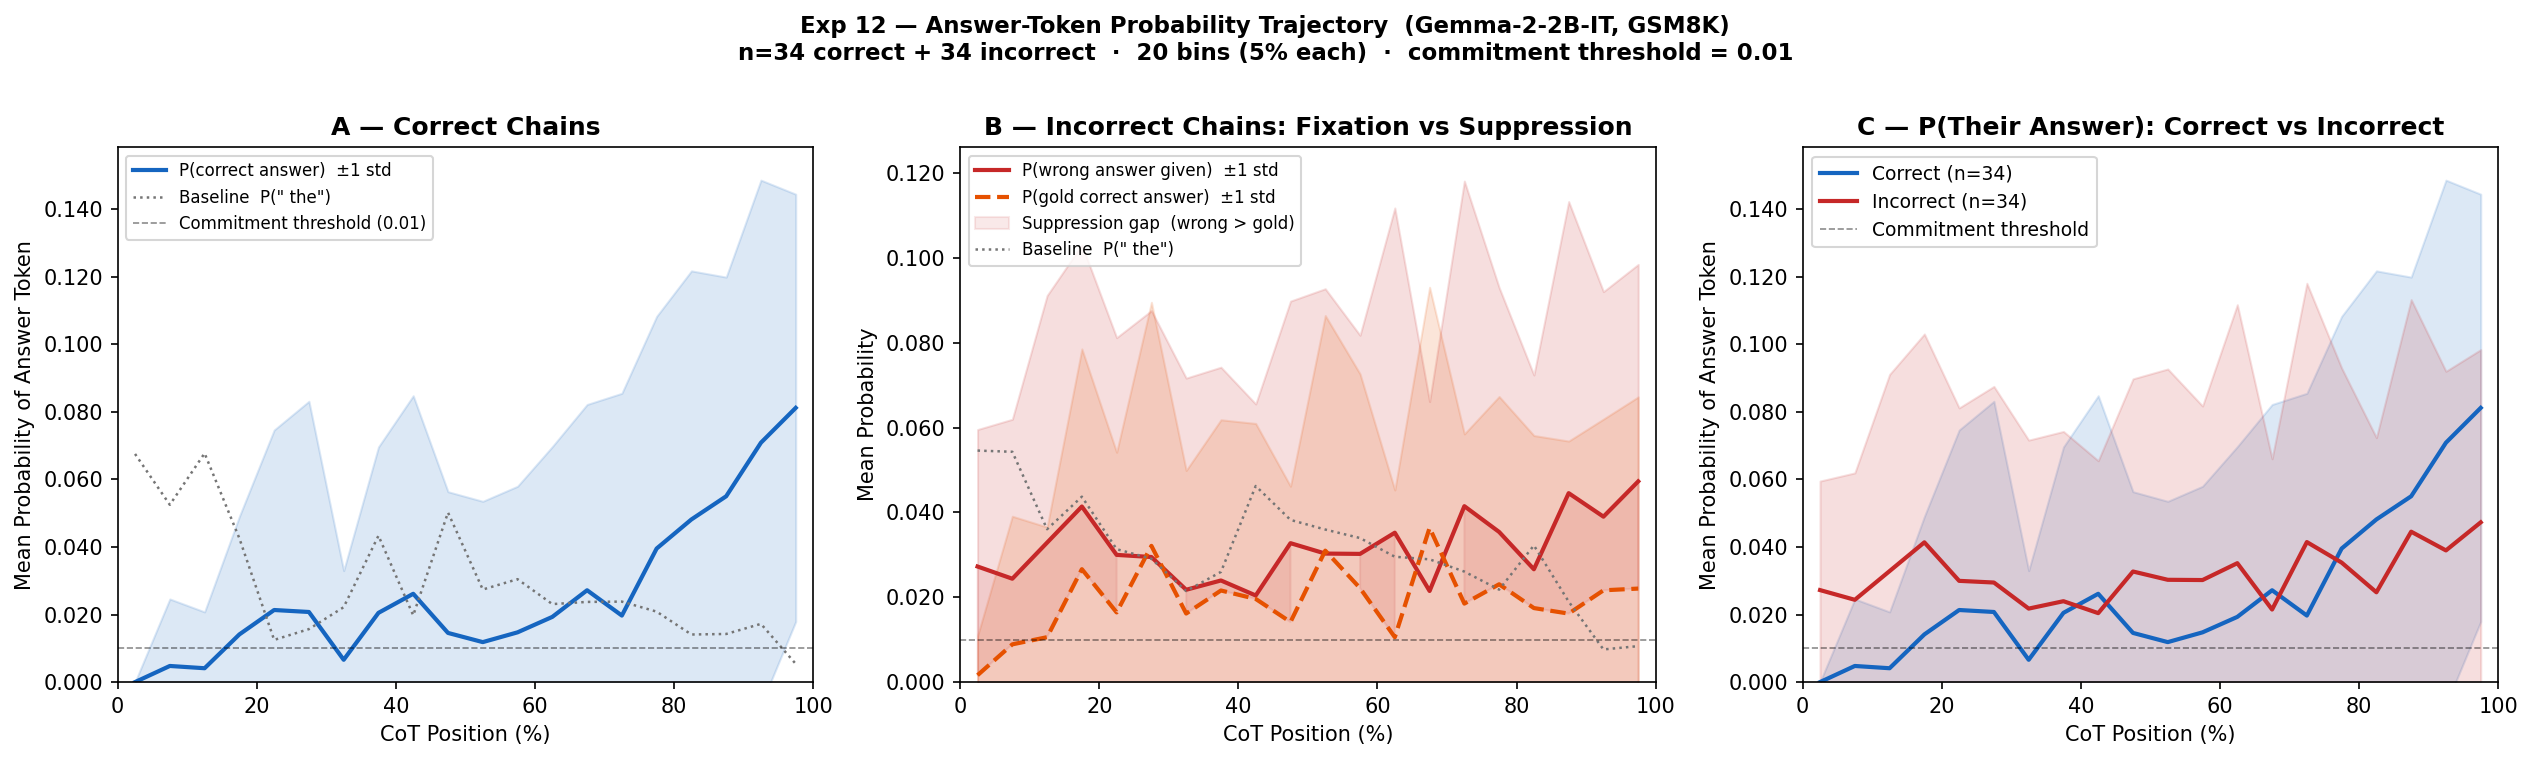


**Figure 2 — Commitment & Peak Fraction Distributions (violin + strip, Mann–Whitney)**

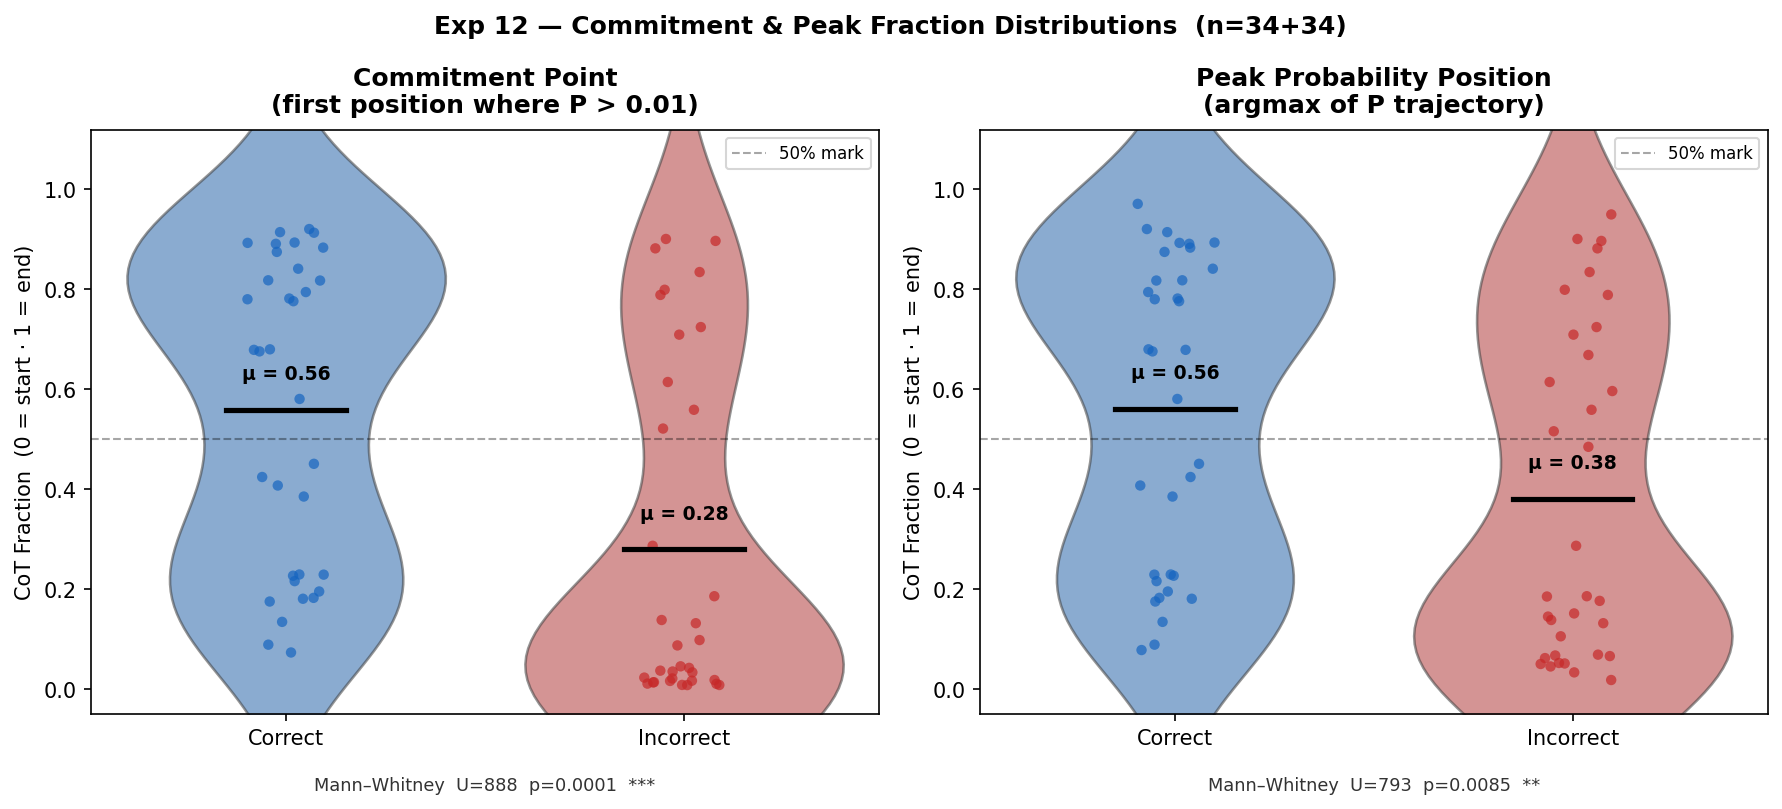


**Figure 3 — Per-Chain Heatmap: P(answer token) sorted by commitment point**

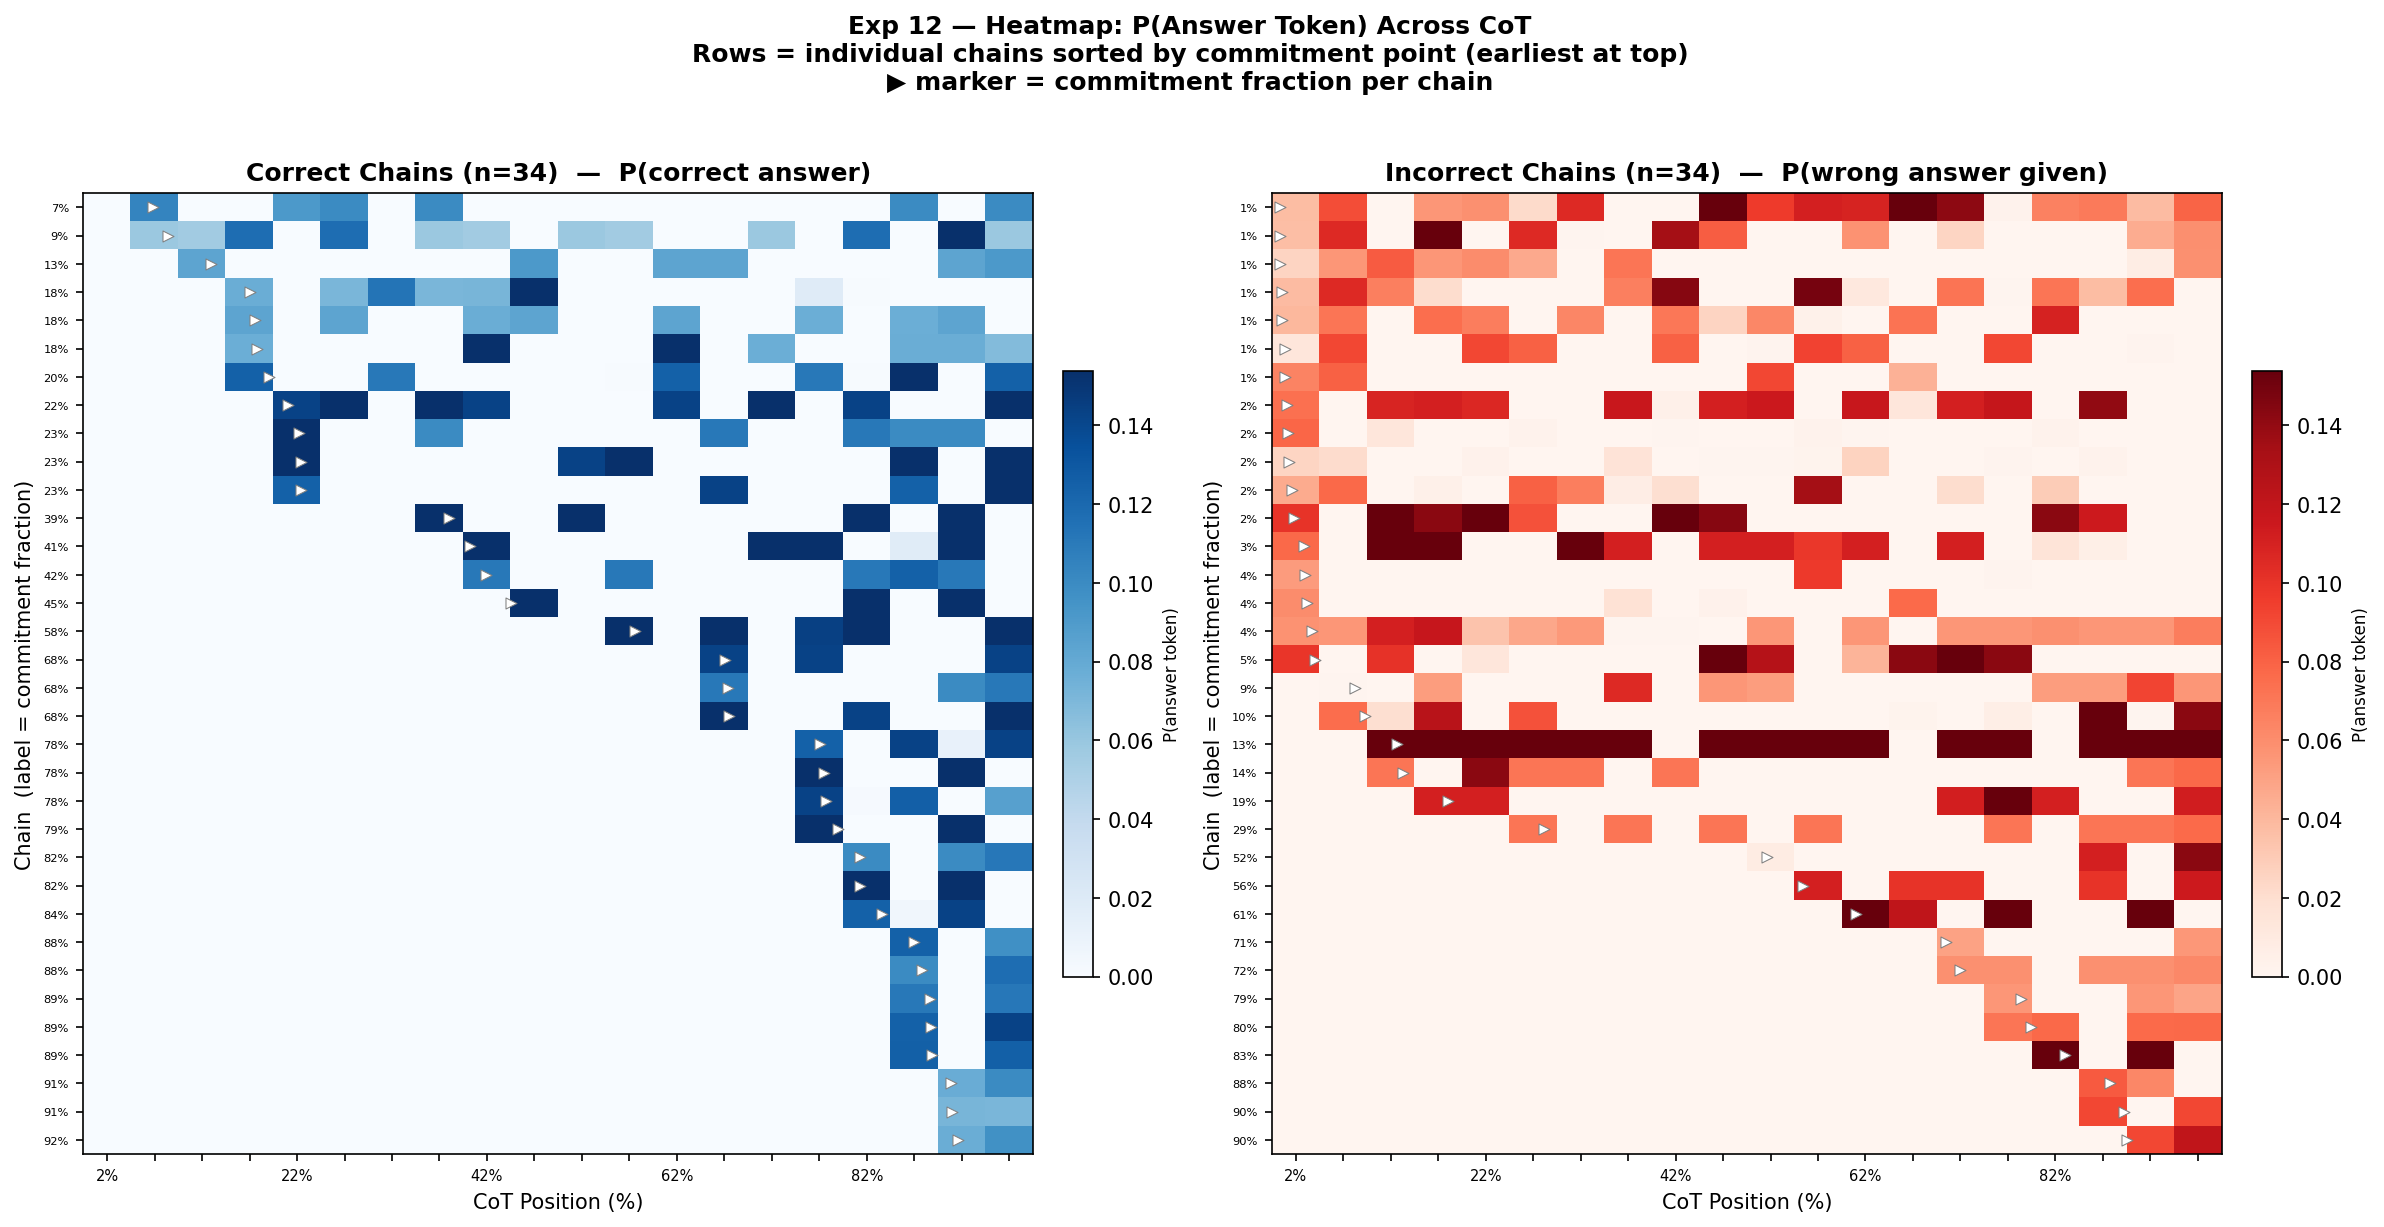


**Figure 4 — Suppression Analysis: P(wrong) vs P(gold) in Incorrect Chains**

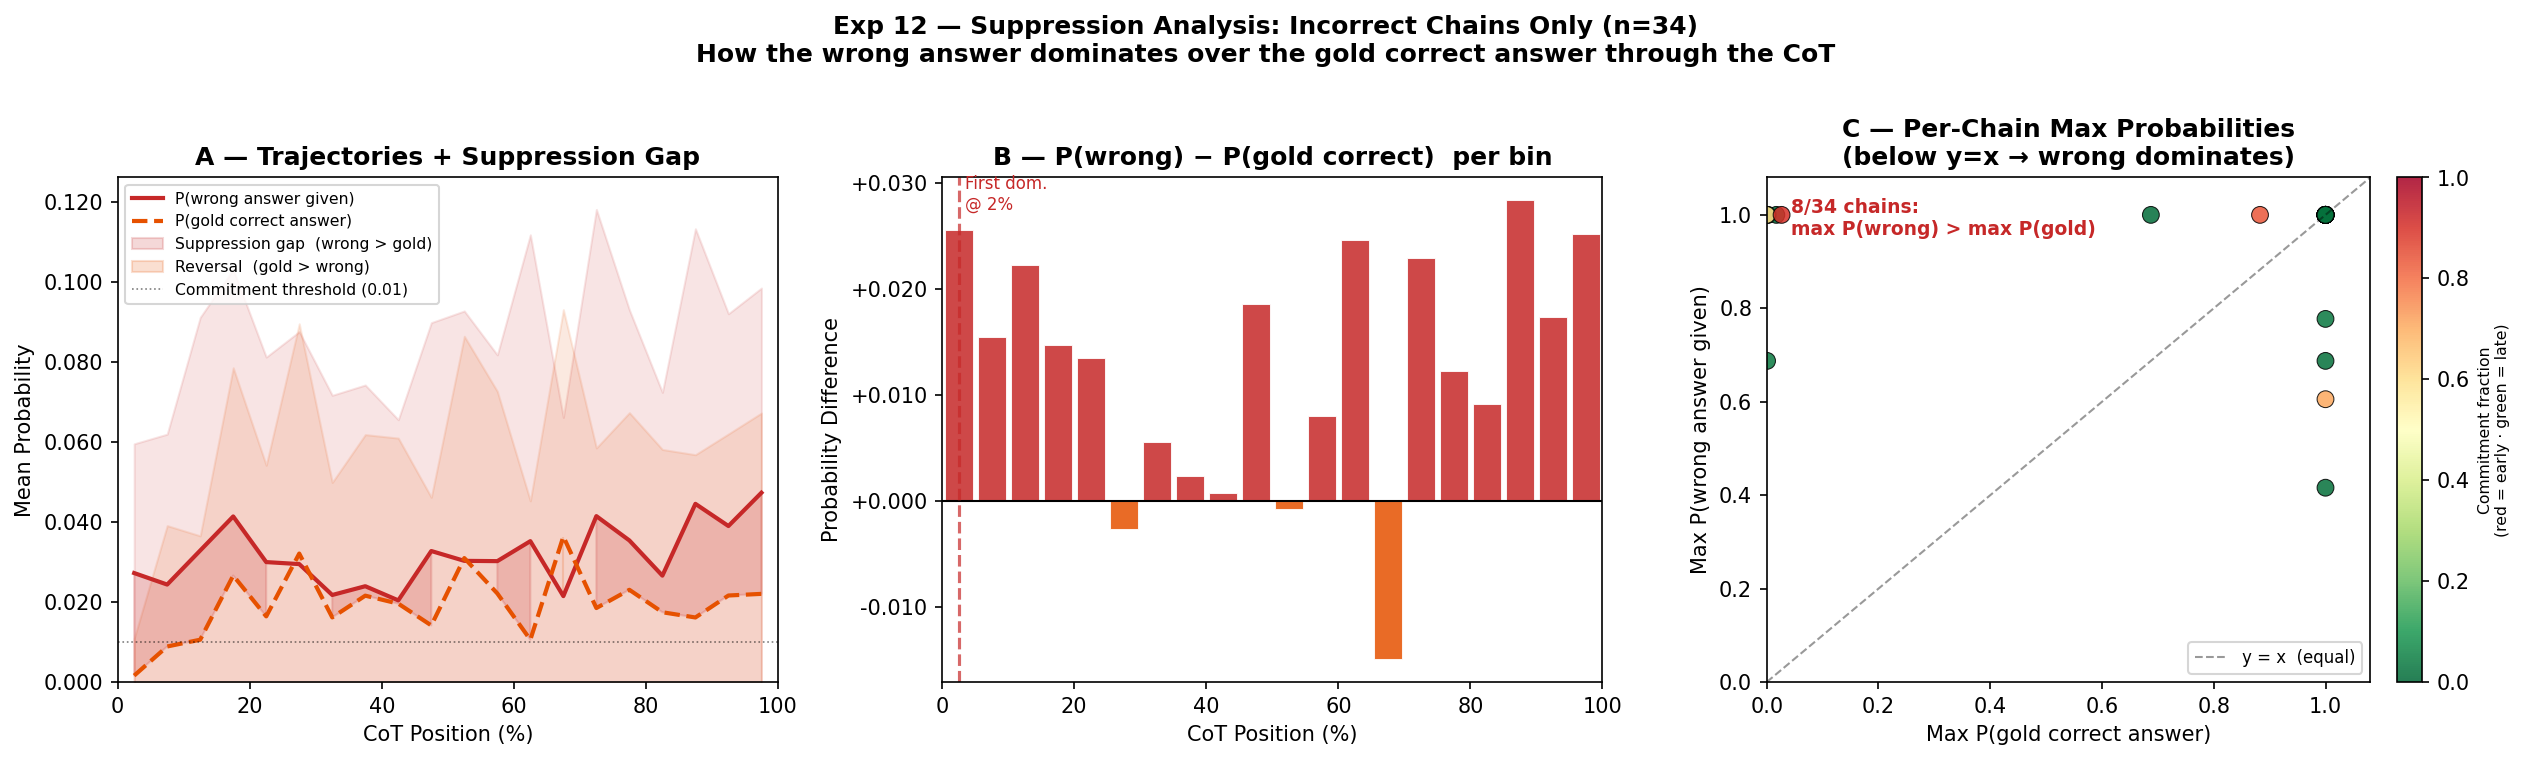


**Figure 5 — All Digit Probabilities (0-9) for 2 Correct + 2 Incorrect Example Chains**

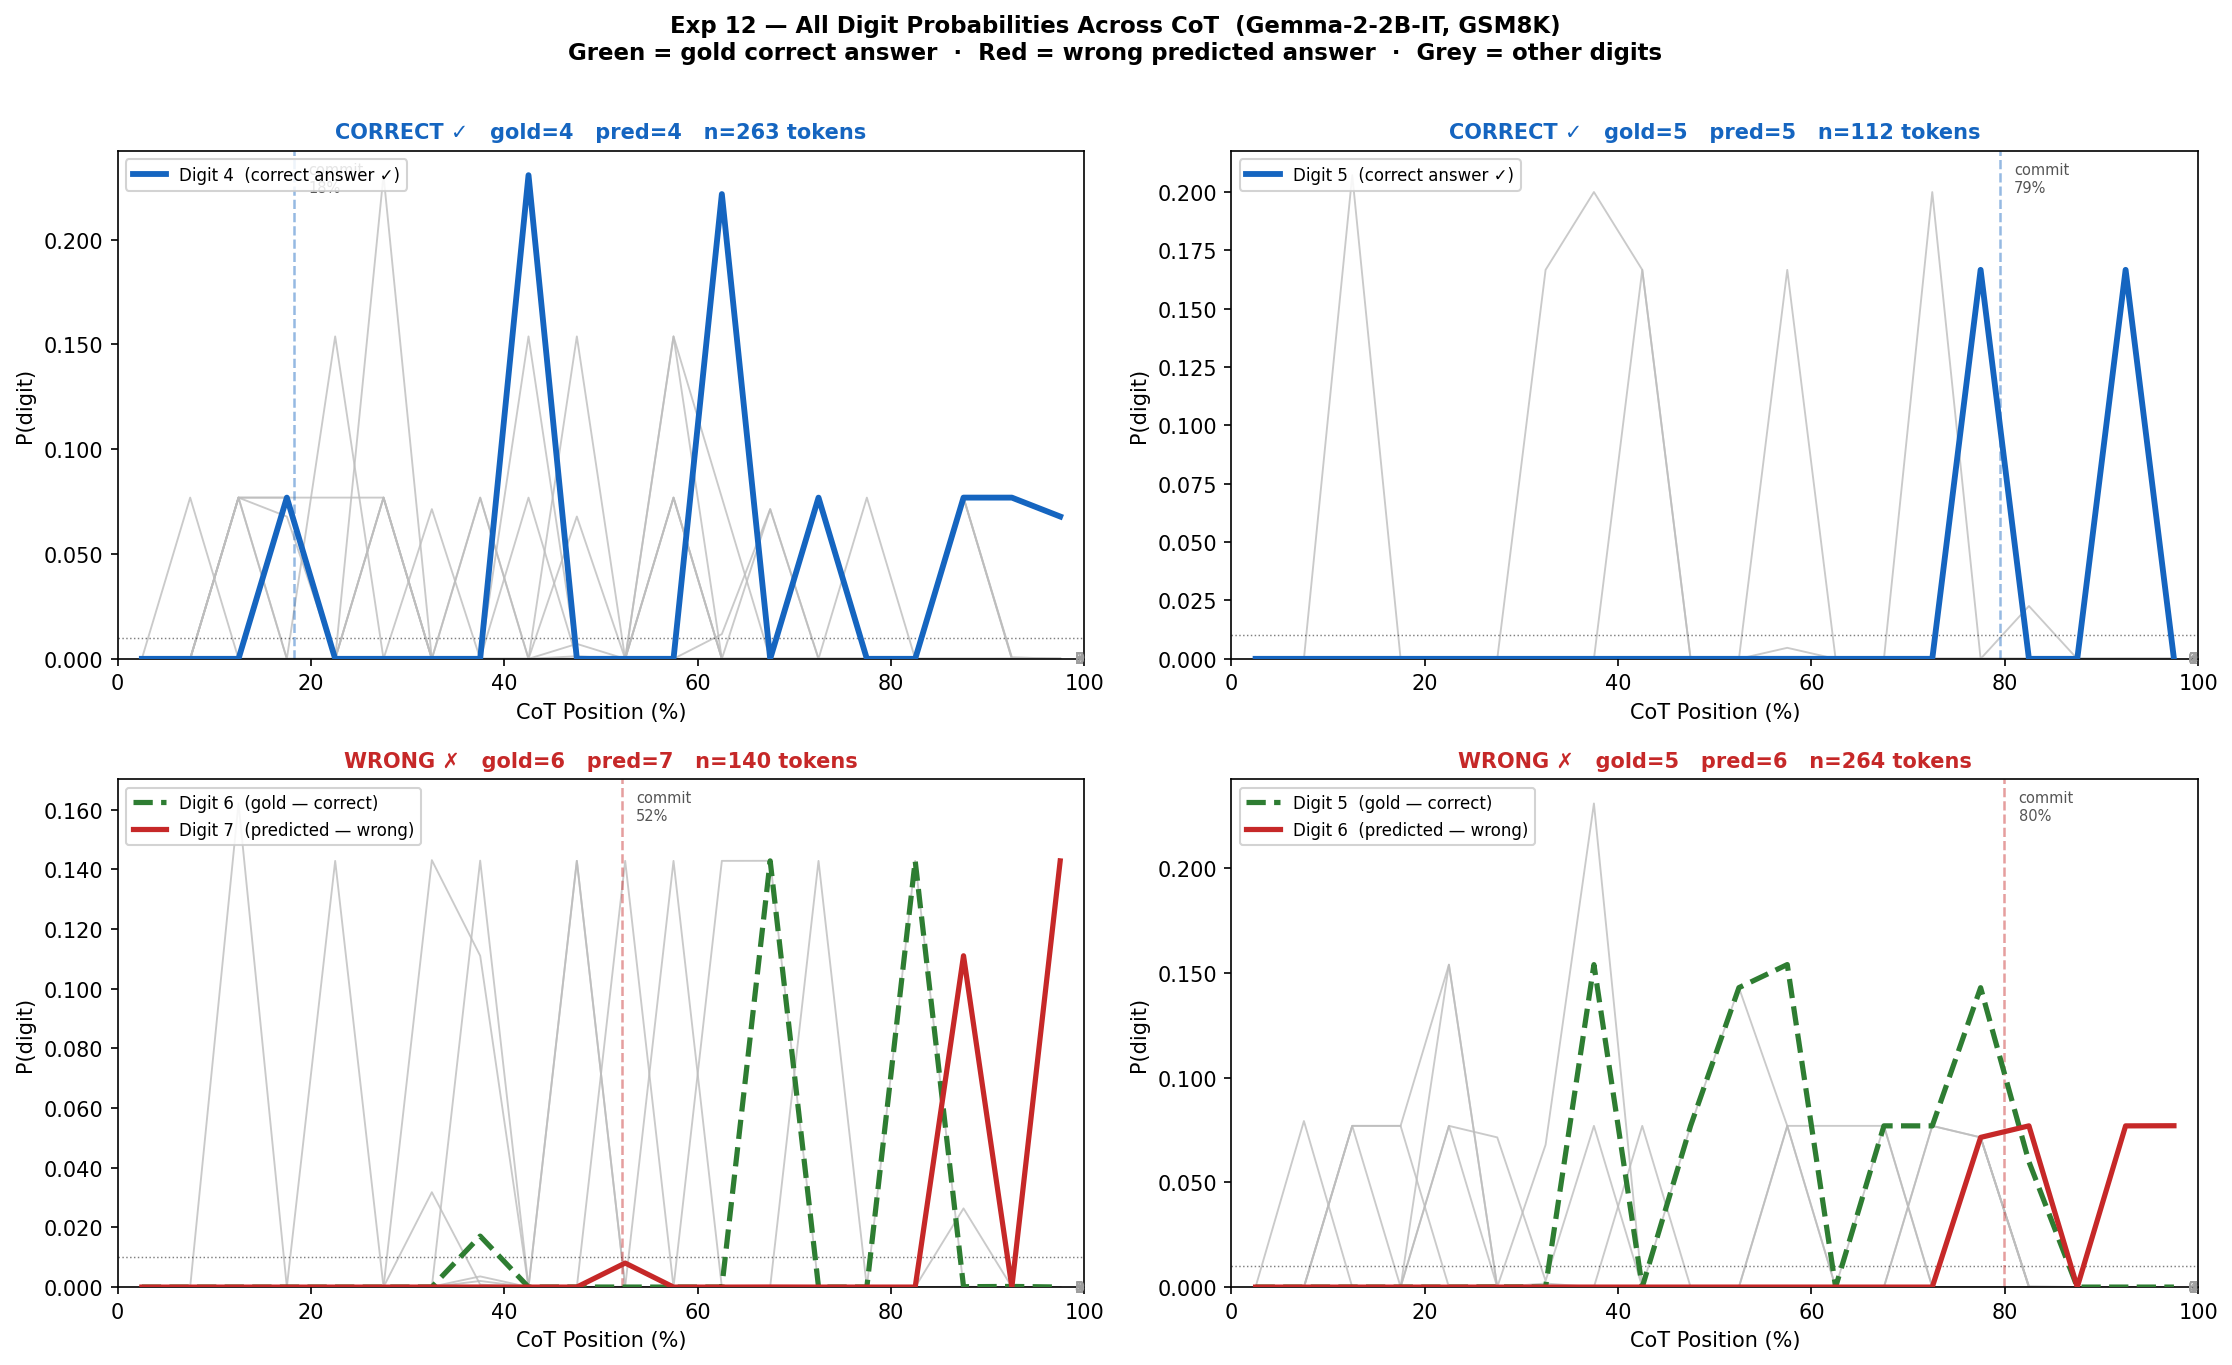
